# part 2

## Imports

In [234]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from sklearn import linear_model
import seaborn as sns
import random 
import statistics 
import math 
import scipy as sc
from scipy.stats import chisquare
from collections import Counter
from scipy import stats

random.seed(42)

## 7

In [235]:
def continous_time_state_distribution(n, Q):
    survival_distribution = []
    states = []

    for _ in range(n):
        state = 0 
        survivaltime = 0
        while state != 4:
            transition_time = np.random.exponential(1/-Q[state][state])
            survivaltime += transition_time

            prop_list = [-q / Q[state][state] for q in Q[state][state+1:]]
            state = np.random.choice(np.arange(state+1, 5), p=prop_list)

        survival_distribution.append(survivaltime)

    mean_survival_time = np.mean(survival_distribution)

    return survival_distribution, mean_survival_time

In [236]:
n_women = 1000
Q = np.array([
    [-0.0085,  0.005,  0.0025, 0,      0.001],
    [0,      -0.014,   0.005,  0.004,  0.005],
    [0,       0,      -0.008,  0.003,  0.005],
    [0,       0,       0,     -0.009,  0.009],
    [0,       0,       0,      0,      0]
])

random.seed(42)
survival_distribution, mean_survival_time = continous_time_state_distribution(n_women, Q)

In [237]:
mean_survival_time

276.72088628565507

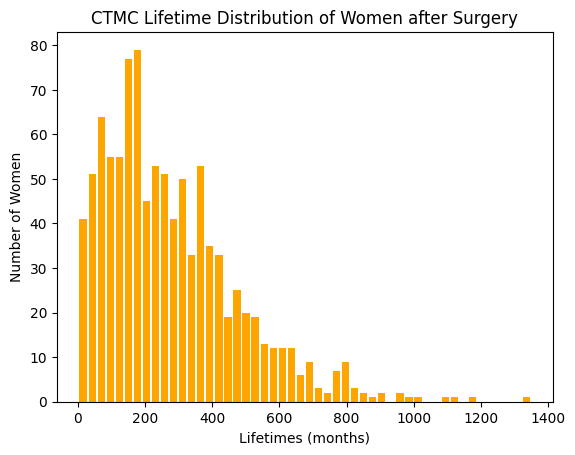

In [238]:
plt.hist(survival_distribution, bins=50, rwidth=0.8, color="orange")
plt.xlabel('Lifetimes (months)')
plt.ylabel('Number of Women')
plt.title('CTMC Lifetime Distribution of Women after Surgery')
plt.savefig("/Users/zachariasvigknudstorp/Desktop/CTMC_lifetime_distribution.pdf", bbox_inches="tight")
plt.show()

In [239]:
std = np.std(survival_distribution)
confidence_interval_mean = (round(mean_survival_time - 1.96 * std / np.sqrt(n_women),4), round(mean_survival_time + 1.96 * std / np.sqrt(n_women),4))
chi_square_975 = sc.stats.chi2.ppf(0.975,df=(n_women-1))
chi_square_025 = sc.stats.chi2.ppf(0.025,df=(n_women-1))
confidence_interval_std = (
    round(np.sqrt((n_women - 1) * std**2 / chi_square_975),4),
            round(np.sqrt((n_women - 1) * std**2 / chi_square_025),4)
)


df = pd.DataFrame({
    "Mean survival time": [mean_survival_time],
    "Standard deviation": [std],
    'CI mean' : [confidence_interval_mean],
    'CI standard deviation' : [confidence_interval_std]
})

print(df)
print(df.to_latex(
    index=False,
    float_format="%.4f"
))

   Mean survival time  Standard deviation              CI mean  \
0          276.720886          199.932329  (264.329, 289.1128)   

  CI standard deviation  
0  (191.5376, 209.1023)  
\begin{tabular}{rrll}
\toprule
Mean survival time & Standard deviation & CI mean & CI standard deviation \\
\midrule
276.7209 & 199.9323 & (264.329, 289.1128) & (191.5376, 209.1023) \\
\bottomrule
\end{tabular}



In [240]:
def continous_time_state_distribution_distant(n, Q):
    survival_distribution = []
    distant_after_t = []


    for _ in range(n):
        state = 0 
        survival_time = 0
        was_distant = False
        while state != 4:
            transition_time = np.random.exponential(1/-Q[state][state])
            survival_time += transition_time

            prop_list = [-q / Q[state][state] for q in Q[state][state+1:]]
            state = np.random.choice(np.arange(state+1, 5), p=prop_list)

            if (state in [2, 3]) and (survival_time > 30.5):
                was_distant = True
                
        distant_after_t.append(was_distant)
        
        survival_distribution.append(survival_time)

    distant_fraction = sum(distant_after_t) / n
    mean_survival_time = np.mean(survival_distribution)

    return survival_distribution, distant_fraction, mean_survival_time

In [241]:
survival_distribution, distant_fraction, mean_survival_time = continous_time_state_distribution_distant(n_women, Q)

In [242]:
print(f"Distant fraction after 30.5 months: {distant_fraction}")

df = pd.DataFrame({
    "Distant fraction after 30.5 months:": [distant_fraction],
})

print(df)
print(df.to_latex(
    index=False,
    float_format="%.4f"
))

Distant fraction after 30.5 months: 0.593
   Distant fraction after 30.5 months:
0                                0.593
\begin{tabular}{r}
\toprule
Distant fraction after 30.5 months: \\
\midrule
0.5930 \\
\bottomrule
\end{tabular}



## 8

In [243]:
p0 = np.array([1,0,0,0])
Qs = Q[:4,:4]

def F(t):
    return float((1- p0 @ sc.linalg.expm(Qs * t) @ np.ones(4)))

theo = [F(t) for t in range(1000)]

In [244]:
def continous_time_state_distribution(n, Q):
    survival_distribution = []
    states = []

    for _ in range(n):
        state = 0 
        survivaltime = 0
        while state != 4:
            transition_time = np.random.exponential(1/-Q[state][state])
            survivaltime += transition_time

            prop_list = [-q / Q[state][state] for q in Q[state][state+1:]]
            state = np.random.choice(np.arange(state+1, 5), p=prop_list)

        survival_distribution.append(survivaltime)

    mean_survival_time = np.mean(survival_distribution)

    N = len(survival_distribution)
    empirical_cdf = [sum(dead <= t for dead in survival_distribution) / len(survival_distribution) for t in range(n)]

    return survival_distribution, mean_survival_time, empirical_cdf

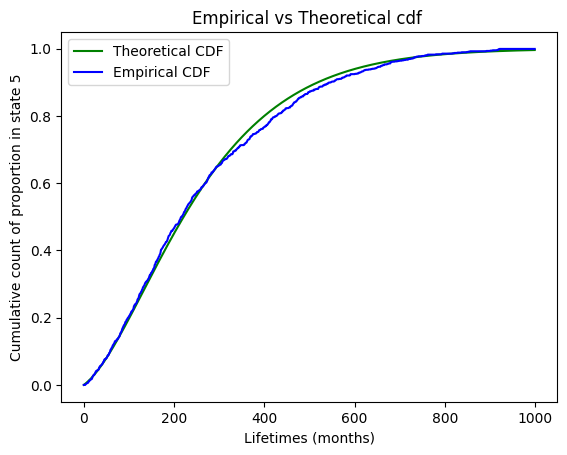

In [245]:

survival_distribution, mean_survival_time, empirical = continous_time_state_distribution(n_women, Q)
theoretical_cdf = [F(t) for t in range(1000)]

plt.plot(theoretical_cdf, color="green",label='Theoretical CDF' )
plt.plot(empirical, color="blue", label='Empirical CDF')
plt.xlabel('Lifetimes (months)')
plt.ylabel('Cumulative count of proportion in state 5')
plt.legend()
plt.title('Empirical vs Theoretical cdf ')
plt.savefig("/Users/zachariasvigknudstorp/Desktop/empirical_vs_theoretical_cdf.pdf", bbox_inches="tight")
plt.show()

In [246]:
F_vec = np.vectorize(F)
ks_stat, p_value = stats.ks_1samp(survival_distribution, F_vec)
#print(f"KS statistic: {ks_stat:.4f}, p-value: {p_value:.4f}")

df = pd.DataFrame({
    "KS statistic": [ks_stat],
    "KS p-value": [p_value],
})


print(df.to_latex(
    index=False,
    float_format="%.4f"
))
print(df)

\begin{tabular}{rr}
\toprule
KS statistic & KS p-value \\
\midrule
0.0353 & 0.1604 \\
\bottomrule
\end{tabular}

   KS statistic  KS p-value
0      0.035349    0.160375


## 9

Kaplan Meier subtracts the number of observed from the d(t) as it accounts for not knowing some units outcome. E.g. if we simulated women, till time month = 120, and then stopped, we would not know the outcome of some woman. Therefore in Kaplan Meier the N is subtracted as prevents under/over counting. However as this simulation is build up around simulating every woman to the end, and not a specific time step. The KM estimate of S(t) reduces to 1 minus the empirical cdf. 

cdf --> what proportion of all simulated women are dead at time t 
S(t) --> what proportion of all simulated women are alive at time t 

In [247]:
n_women = 1000
survival_distribution, mean_survival_time, empirical = continous_time_state_distribution(n_women, Q)
S = [1 - empirical[i] for i in range(len(empirical))]

theoritical_cdf = [F(t) for t in range(1200)]
theoritical_survival = [1 - theoritical_cdf[i] for i in range(len(theoritical_cdf))] 


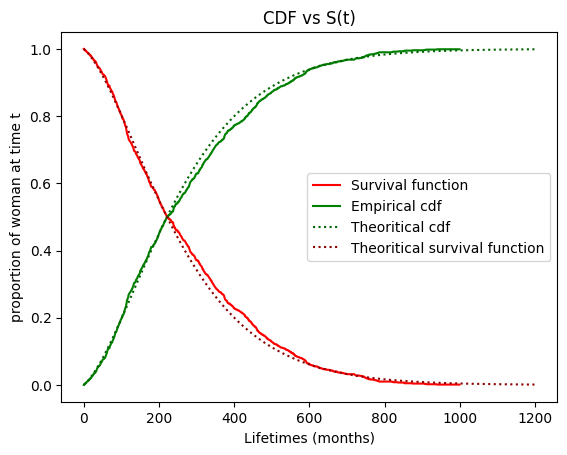

In [248]:
plt.plot(S, color="red", label='Survival function')
plt.plot(empirical, color="green", label='Empirical cdf')
plt.plot(theoritical_cdf, color='darkgreen',linestyle = 'dotted',label='Theoritical cdf')
plt.plot(theoritical_survival, color='darkred',linestyle = 'dotted',label='Theoritical survival function')
plt.xlabel('Lifetimes (months)')
plt.ylabel('proportion of woman at time t')
plt.legend()
plt.title('CDF vs S(t)')
plt.savefig("/Users/zachariasvigknudstorp/Desktop/CDF_vs_S(t).pdf", bbox_inches="tight")
plt.show()

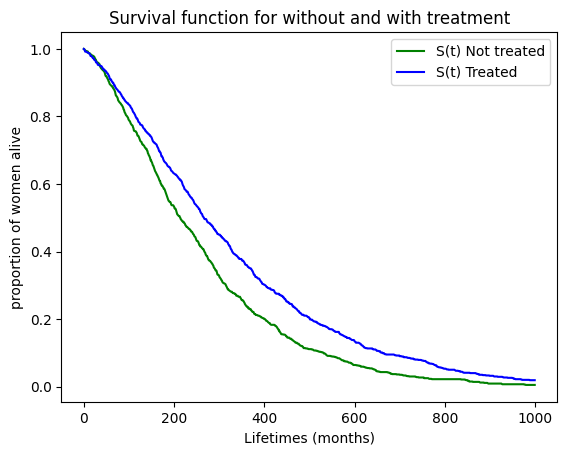

In [249]:
random.seed(42)
n_women = 1000
Q_treated = np.array([
    [-0.00475,  0.0025,  0.00125, 0,      0.001],
    [0,      -0.007,   0,  0.002,  0.005],
    [0,       0,      -0.008,  0.003,  0.005],
    [0,       0,       0,     -0.009,  0.009],
    [0,       0,       0,      0,      0]
])

survival_distribution, mean_survival_time, cdf = continous_time_state_distribution(n_women, Q)
survival_distribution_trated, mean_survival_time_treated, cdf_treated = continous_time_state_distribution(n_women, Q_treated)

S = [1 - cdf[i] for i in range(len(cdf))]
S_treated = [1 - cdf_treated[i] for i in range(len(cdf_treated))]

plt.plot(S, color="green", label='S(t) Not treated')
plt.plot(S_treated, color="blue", label='S(t) Treated')
plt.ylabel('proportion of women alive')
plt.xlabel('Lifetimes (months)')
plt.legend()
plt.title('Survival function for without and with treatment')
plt.savefig("/Users/zachariasvigknudstorp/Desktop/survival_function_treated_vs_notTreated.pdf", bbox_inches="tight")
plt.show()

## 11

The discrete model assume at max one transistion per month. In the CTMC models transistion happens according to an exponential distribution. This is a more realistic scenario as the time between transistion is more or less accelerated vary for the women. However this is itself an assumption of how the time between transistions should be distributed. 

Maybe mention that the exponential distribution is memoryless. The probability of transistion is only dependent on the current state, and not when the women transistioned to that state. consider a women who transistion quickly from surgery to local and distant recurrence, this would seem like the dieseae accelarating. But her probability of transistion to the death state is not dependent on that. 

The problem suggest that the time between transistion should be distributed by Erlang. Erlang is the sum of independent exponentially distributed random variables. The probability of transistioning could be modelleded such that the women have to enter a Erlang chain of exponential distributed parameters and then take the sum of that. not entirely sharp here.... 


Report has a more in depth discussion. 
